# Exercise: Visualisation in Python

## Exercise

We are the team managers of a soccer club and are keen on leveraging data to gain insights into the performance of our players. The dataset at our disposal contains valuable information about each player's skills, age, and overall rating. As managers, we have specific questions in mind that will help us make informed decisions and strategies for the upcoming season.

Let's start by importing the libraries we're going to need and loading the dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
soccer = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/fundamentals/football_players.csv', low_memory=False)
soccer.head()

,Name,Age,Nationality,Overall,Acceleration,Aggression,Agility,Balance,Ball control,Composure,...,Short passing,Shot power,Sliding tackle,Sprint speed,Stamina,Standing tackle,Strength,Vision,Volleys,Preferred Positions
0,Cristiano Ronaldo,32,Portugal,94,89,63,89,63,93,95,...,83,94,23,91,92,31,80,85,88,ST LW
1,L. Messi,30,Argentina,93,92,48,90,95,95,96,...,88,85,26,87,73,28,59,90,85,RW
2,Neymar,25,Brazil,92,94,56,96,82,95,92,...,81,80,33,90,78,24,53,80,83,LW
3,L. Suárez,30,Uruguay,92,88,78,86,60,91,83,...,83,87,38,77,89,45,80,84,88,ST
4,M. Neuer,31,Germany,92,58,29,52,35,48,70,...,55,25,11,61,44,10,83,70,11,GK


In [3]:
# changing the following columns to numeric data type
cols = ['Overall', 'Acceleration', 'Aggression',
       'Agility', 'Balance', 'Ball control', 'Composure', 'Crossing', 'Curve',
       'Dribbling', 'Finishing', 'Free kick accuracy', 'GK diving',
       'GK handling', 'GK kicking', 'GK positioning', 'GK reflexes',
       'Heading accuracy', 'Interceptions', 'Jumping', 'Long passing',
       'Long shots', 'Marking', 'Penalties', 'Positioning', 'Reactions',
       'Short passing', 'Shot power', 'Sliding tackle', 'Sprint speed',
       'Stamina', 'Standing tackle', 'Strength', 'Vision', 'Volleys']

soccer[cols] = soccer[cols].apply(pd.to_numeric, axis=1, errors='coerce')

soccer.info()

<class 'pandas.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 17981 non-null  str    
 1   Age                  17981 non-null  int64  
 2   Nationality          17981 non-null  str    
 3   Overall              17981 non-null  float64
 4   Acceleration         17926 non-null  float64
 5   Aggression           17928 non-null  float64
 6   Agility              17937 non-null  float64
 7   Balance              17941 non-null  float64
 8   Ball control         17888 non-null  float64
 9   Composure            17923 non-null  float64
 10  Crossing             17915 non-null  float64
 11  Curve                17920 non-null  float64
 12  Dribbling            17890 non-null  float64
 13  Finishing            17905 non-null  float64
 14  Free kick accuracy   17948 non-null  float64
 15  GK diving            17966 non-null  float64
 1

##### Checking the descriptive statistics of the dataset

In [9]:
soccer.describe()

,Age,Overall,Acceleration,Aggression,Agility,Balance,Ball control,Composure,Crossing,Curve,...,Reactions,Short passing,Shot power,Sliding tackle,Sprint speed,Stamina,Standing tackle,Strength,Vision,Volleys
count,17981.000000,17981.000000,17926.000000,17928.00000,17937.000000,17941.000000,17888.000000,17923.000000,17915.000000,17920.000000,...,17914.000000,17876.000000,17929.000000,17918.000000,17906.000000,17915.000000,17901.000000,17913.000000,17904.000000,17950.000000
mean,25.144541,66.247984,103.446893,77.59923,98.150248,86.616911,121.420338,103.764995,86.550600,62.586496,...,121.637937,115.298557,83.046796,89.598672,119.034849,123.126151,109.390425,116.040138,91.195878,54.622507
std,4.614272,6.987965,986.386054,768.79730,910.809847,752.123941,1236.108966,1028.086556,912.376407,623.794730,...,1161.367097,1157.803920,811.145271,1074.217147,1185.940156,1261.551333,1286.912547,1148.520031,945.840135,523.716920
min,16.000000,46.000000,11.000000,11.00000,14.000000,11.000000,8.000000,5.000000,5.000000,6.000000,...,28.000000,10.000000,3.000000,4.000000,11.000000,12.000000,4.000000,12.000000,10.000000,4.000000
25%,21.000000,62.000000,56.000000,43.00000,55.000000,56.000000,53.000000,51.000000,38.000000,34.000000,...,55.250000,53.000000,46.000000,24.000000,57.000000,56.000000,26.000000,58.000000,43.000000,30.000000
50%,25.000000,66.000000,67.000000,59.00000,65.000000,66.000000,63.000000,60.000000,54.000000,48.000000,...,62.000000,62.000000,59.000000,51.000000,67.000000,66.000000,54.000000,66.000000,54.000000,44.000000
75%,28.000000,71.000000,75.000000,69.00000,74.000000,74.000000,69.000000,67.000000,64.000000,62.000000,...,68.000000,68.000000,69.000000,64.000000,75.000000,74.000000,66.000000,74.000000,64.000000,57.000000
max,47.000000,94.000000,33270.000000,43130.00000,30164.000000,31472.000000,43145.000000,27150.000000,27150.000000,43131.000000,...,27760.000000,28856.000000,29677.000000,43372.000000,32905.000000,43433.000000,43144.000000,31868.000000,28216.000000,43129.000000


##### Replacing values that exceed 100% with NAN.

In [10]:
for column in soccer.describe().columns:
    soccer[column] = soccer[column].apply(lambda x: x if x <= 100 else np.nan)

soccer.describe()

,Age,Overall,Acceleration,Aggression,Agility,Balance,Ball control,Composure,Crossing,Curve,...,Reactions,Short passing,Shot power,Sliding tackle,Sprint speed,Stamina,Standing tackle,Strength,Vision,Volleys
count,17981.000000,17981.000000,17897.000000,17913.000000,17910.000000,17924.000000,17840.000000,17887.000000,17885.000000,17908.000000,...,17866.000000,17832.000000,17908.000000,17886.000000,17867.000000,17873.000000,17857.000000,17877.000000,17874.000000,17940.000000
mean,25.144541,66.247984,64.576521,55.791492,63.333613,63.803894,58.071469,57.877341,49.725301,47.261112,...,61.898802,58.263964,55.622292,45.496645,64.795713,63.233201,47.352187,65.279130,52.967495,43.198495
std,4.614272,6.987965,14.918313,17.476572,14.802800,14.100950,16.834554,12.938165,18.474237,18.463394,...,9.176709,14.947943,17.408483,21.489926,14.649127,15.942738,21.851023,12.618415,14.387015,17.734259
min,16.000000,46.000000,11.000000,11.000000,14.000000,11.000000,8.000000,5.000000,5.000000,6.000000,...,28.000000,10.000000,3.000000,4.000000,11.000000,12.000000,4.000000,12.000000,10.000000,4.000000
25%,21.000000,62.000000,56.000000,43.000000,55.000000,56.000000,53.000000,51.000000,37.000000,34.000000,...,55.000000,53.000000,46.000000,23.000000,57.000000,56.000000,26.000000,58.000000,43.000000,30.000000
50%,25.000000,66.000000,67.000000,59.000000,65.000000,66.000000,63.000000,60.000000,54.000000,48.000000,...,62.000000,62.000000,59.000000,51.000000,67.000000,66.000000,54.000000,66.000000,54.000000,44.000000
75%,28.000000,71.000000,75.000000,69.000000,74.000000,74.000000,69.000000,67.000000,64.000000,62.000000,...,68.000000,68.000000,69.000000,64.000000,75.000000,74.000000,66.000000,74.000000,64.000000,57.000000
max,47.000000,94.000000,96.000000,96.000000,96.000000,96.000000,95.000000,96.000000,91.000000,92.000000,...,96.000000,92.000000,94.000000,91.000000,96.000000,95.000000,92.000000,98.000000,94.000000,91.000000


### Exercise 1

Now that we've loaded the dataset, we are curious about how players from different nationalities perform on average. We want to compare the overall ratings across the countries producing the highest number of players. We decide to create a bar graph to compare the average overall ratings of players, specifically for the top five nationalities, **based on the total number of players per country**. This insight will help us identify potential strengths within our team.

Create a bar graph using `Matplotlib` to represent the average overall rating for players from the top five nationalities (**based on the number of players in each nationality**). Be sure to customise the graph as you see fit.

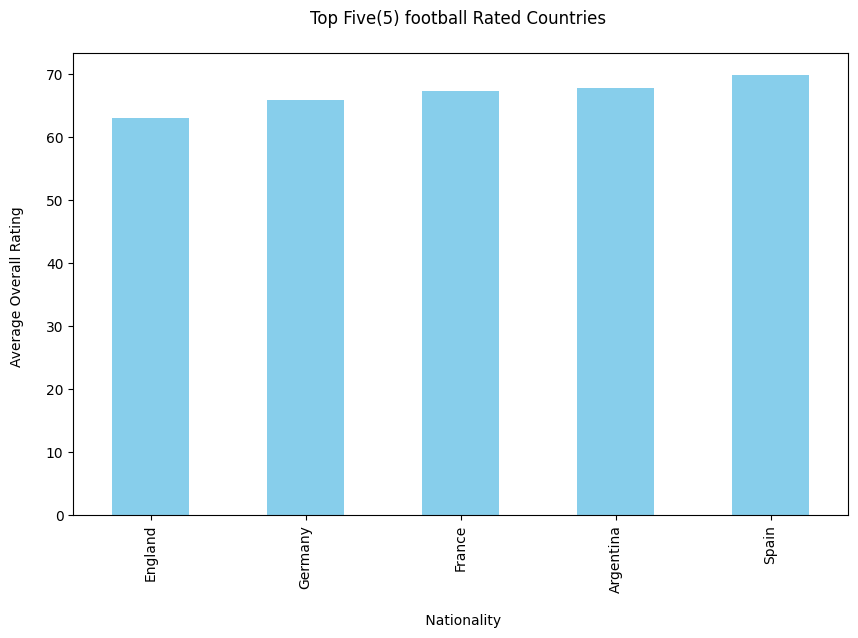

In [11]:
# Identifying the top five(5) nationalities based on player count
top_country = soccer['Nationality'].value_counts().head(5).index

# Filtering the dataset based on the top five(5) nationalities
top_players = soccer[soccer['Nationality'].isin(top_country)]

# Calculating the overall average rating for each nationality
average_ratings = top_players.groupby('Nationality')['Overall'].mean()

# plotting the graph
plt.figure(figsize=(10,6))
average_ratings.sort_values().plot(kind='bar', color='skyblue')
plt.xlabel('\n Nationality')
plt.ylabel('Average Overall Rating \n')
plt.title('Top Five(5) football Rated Countries \n')
plt.show()

The barchat shows that Spain has the highest overall rating amongst the top five nationalities, while England has the lowest.

### Exercise 2

As we delve deeper into player analysis, we wonder about the age distribution of our team. A pie chart showcasing the percentage distribution of player ages will provide a clear picture. Understanding the age demographics helps us plan for the team's future and potential recruitment strategies. We have decided to categorise players into specific age groups, specifically `[15-19]`, `[20-24]`, `[25-29]`, `[30-34]`, and `[35+]`.

Generate a pie chart to visualise the percentage distribution of player ages. 

**Hint**: `pd.cut` is a function in the Pandas library designed for binning or categorising continuous data into discrete intervals, also known as bins. This function is particularly useful when dealing with numerical data that we want to group into meaningful ranges. We can use `pd.cut` to help us create a more interpretable representation of player ages by categorising them into specific age groups.

**Syntax**: 

`pd.cut(x, bins)`

* `x`: The input array or Series that we want to bin.
* `bins`: Defines the bin edges. It can be an integer specifying the number of equal-width bins or a sequence specifying the bin edges.

Use bins of `[15, 20, 25, 30, 35]` to categorise players into specific age groups before plotting the pie chart.

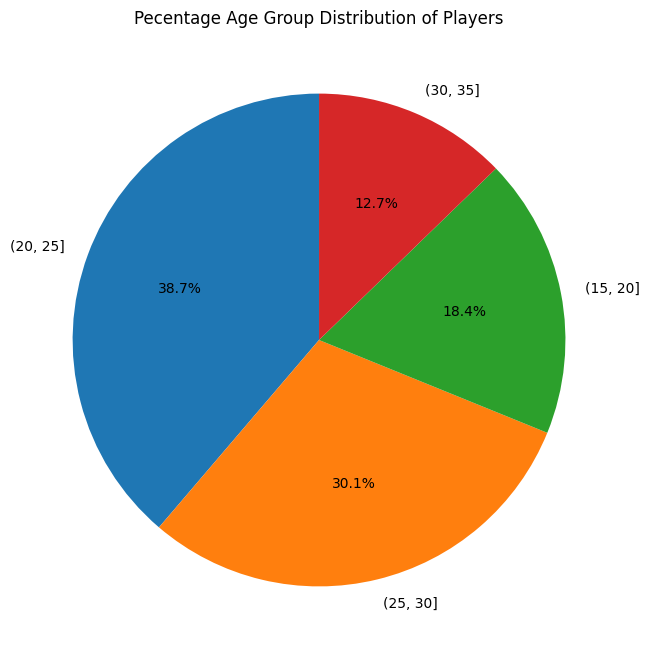

In [35]:
# Bins ages into groups
age_bins = [15, 20, 25, 30, 35]
soccer['Age group'] = pd.cut(soccer['Age'], bins=age_bins)

# Plotting the Pie chart
plt.figure(figsize=(8,8))
soccer['Age group'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Pecentage Age Group Distribution of Players')
plt.show()

The 20-25 age group have the highest percentage of players population distribution atabout 39%, players above 30 years have the lowest player population at about 13%.

### Exercise 3

To enhance our team's fitness and agility, we decide to explore how certain skills, like `Acceleration` and `Sprint speed`, vary across different age groups. A line graph depicting the trends will guide our training and conditioning strategies for players of different ages.

Create a line graph using `Matplotlib` to show the trend of average `Acceleration` and `Sprint speed` across different age groups. Customise the graph appropriately.

Assume that the age bins are defined as `[15, 20, 25, 30, 35]`.

<Figure size 1200x800 with 0 Axes>

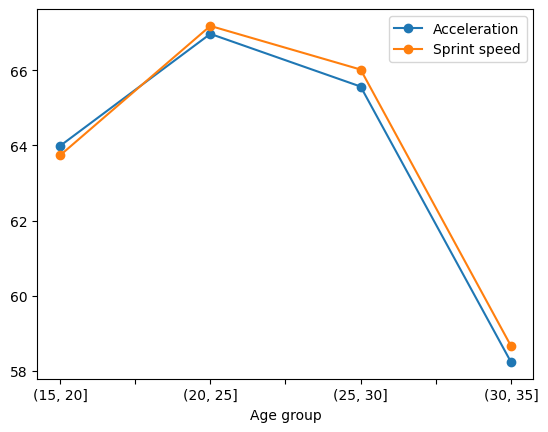

In [15]:
# Filtering acceleration and sprint speed, and grouping by age
age_group_skill = soccer.groupby('Age group')[['Acceleration', 'Sprint speed']].mean()

#Plotting the line graph
plt.figure(figsize=(12,8))
age_group_skill.plot(kind='line', marker='o')
plt.show()

From the Linechart both sprint speed and acceleration increased between the age of 15 to 25. However both tends to decrease after the age of 25, with a sharp decline at 30 onwards.

### Exercise 4

Focused on excellence, we narrow our analysis to players from the top three nationalities based on the highest average `Overall` rating. Slicing the dataset, we create a box plot to compare skill distributions, providing a detailed profile of the top-performing players.

Slice the dataset to only include players from the **top three nationalities** with the highest average `Overall` rating. Then, create a box plot using Seaborn to compare the distribution of specific skills, including `Dribbling`, `Short passing`, `Shot power`, and `Ball control` for players from these nations.

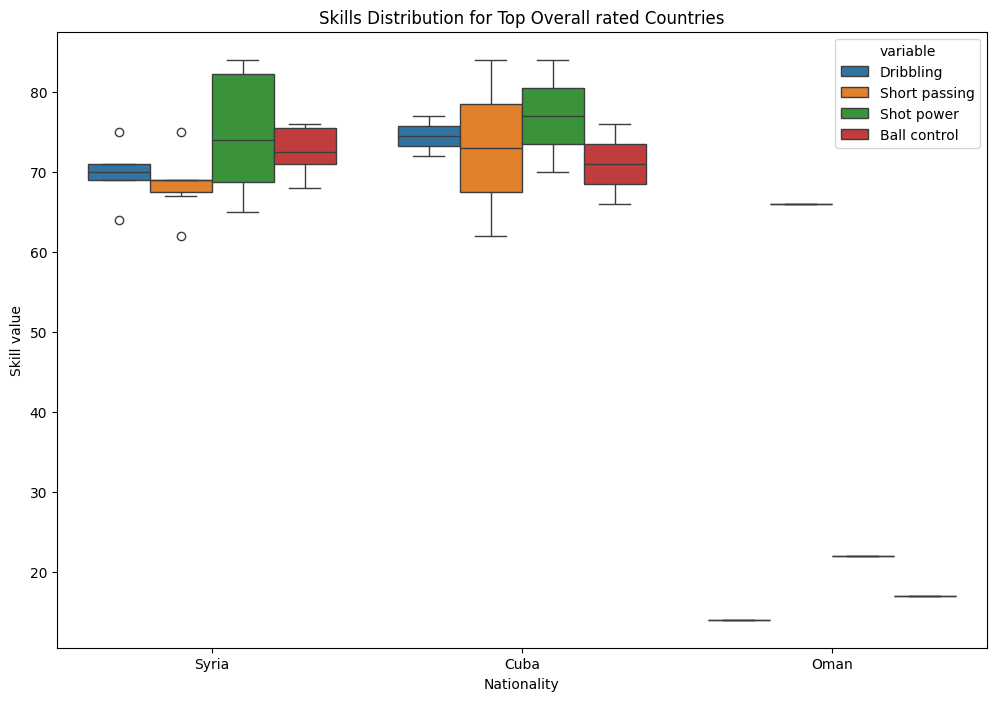

In [39]:
# Nationalities with the top three(3) highest average overall ratings
top_three_countries = soccer.groupby('Nationality')['Overall'].mean().nlargest(3).index


# filtering the dataset for top average overall rated countries
top_countries_data = soccer[soccer['Nationality'].isin(top_three_countries)]

# skills we're comparing
skills = ['Dribbling', 'Short passing', 'Shot power', 'Ball control']

#plotting the graph
plt.figure(figsize=(12,8))
sns.boxplot(x='Nationality', y='value', hue='variable', data=pd.melt(top_countries_data, id_vars=['Nationality'], value_vars=skills))
plt.title('Skills Distribution for Top Overall rated Countries')
plt.xlabel('Nationality')
plt.ylabel('Skill value')
plt.show()

The resulting plot is a box plot with distinct boxes for each selected skill (i.e. `Dribbling`, `Short passing`, ` Shot power`, `Ball control`) for players from `Syria`, `Cuba`, and `Oman`. The boxes illustrate the interquartile range (IQR) and median, while the whiskers depict the range of values. Outliers can also be seen, giving insights into the variation of these skills among players from different nationalities. Overall, the plot aids in understanding the comparative skill distribution and potential areas for improvement or emphasis in training for players from the identified top-performing nationalities.

### Exercise 5

Embracing modern tools, we want to utilise Plotly to create an interactive visualisation. This dynamic plot will empower us to explore the intricate relationships between our categories. We also want to include hover information to add an extra layer of insight for more informed decision-making.

Implement an interactive visualisation using Plotly to allow users to explore the relationship between `Strength`, `Vision`, and the `Overall` rating using the **hover information** feature to allow the user to have an interactive view of the data.

Arrange the plot as follows:

* Place `Strength` on the x-axis.
* Place `Vision` on the y-axis.
* Colour-code the points to represent the `Overall` rating.
* Include a hover that has the name of the player as well as the  `Strength`, `Vision`, and `Overall` ratings for each player.

In [40]:
import plotly.express as px

# Scatter plot using Plotly
fig = px.scatter(soccer, x='Strength', y='Vision', color='Overall', hover_name='Name',
                 title='Interactive Scatter Plot of Strength and Vision vs Overall Rating',
                 labels={'Strength': 'Strength Rating', 'Vision': 'Vision Rating', 'Overall': 'Overall Rating'})

# Show the interactive plot
fig.show()

The resulting scatter plot provides an interactive visual representation of the relationship between `Strength` and `Vision` ratings concerning the `Overall` rating for each player, seen when we hover over each point on our plot. We are also able to interactively zoom in and out of the data points in the graph. 